# Arya Phones — Market Simulation

Simulates how **price**, **supplier selection**, and **admin Beta distribution** interact in the MNL demand model.

## Experiments
1. **Single-team frictionless** — effect of price across all feasible sets
2. **Admin distribution effect** — same selections, 5 Beta shapes
3. **Two-team price war** — Team A vs Team B, grid of prices
4. **Two-team Beta sweep** — fixed prices, 5 Beta shapes
5. **Three-team full factorial** — random mix of strategies
6. **Delta (price sensitivity) sweep** — how calibration changes everything

Results are exported to `market_simulation_results.xlsx`.

In [1]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from server.app.service import get_tables
from server.app.optimization_controller import manual_metrics, MaxProfitConfig
from server.app.settings import FIXED_POLICY, GAME_SETTINGS
from server.app.beta_density import BetaDensity
from server.app.mnl_market import BuyerProfile, run_mnl_market
from server.app.customer_segment import CustomerSegment

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

suppliers_df, users_df = get_tables()
N = len(users_df)
print(f'Suppliers: {len(suppliers_df)}  |  User segments: {N}')
print(f'IDs: {sorted(suppliers_df["supplier_id"].tolist())}')


Project root: C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app


Suppliers: 18  |  User segments: 20
IDs: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R']


In [2]:
# Scenario parameters and helper functions

RANDOM_SEED = 20260413
RANDOM_GROUP_COUNT = 10

PRICES = [60, 70, 80, 90, 100, 110, 120, 130, 140]

BETA_CONFIGS = {
    'Uniform (1,1)':          (1.0, 1.0),
    'Bell/Symmetric (3,3)':   (3.0, 3.0),
    'Quality-pref (1.5,5)':   (1.5, 5.0),
    'Price-pref (5,1.5)':     (5.0, 1.5),
    'U-shape (0.5,0.5)':      (0.5, 0.5),
}

PREFERENCE_COLS = [
    c for c in ['w_cost', 'w_env', 'w_social', 'w_low_quality']
    if c in users_df.columns
]

PREFERENCE_LABELS = {
    'w_cost': 'Cost sensitive',
    'w_env': 'Environment first',
    'w_social': 'Social impact',
    'w_low_quality': 'Quality risk avoidance',
}

PREFERENCE_COLORS = {
    'Cost sensitive': '#4C78A8',
    'Environment first': '#72B7B2',
    'Social impact': '#E45756',
    'Quality risk avoidance': '#FF9DA6',
}

def cfg(price=100.0):
    """Build a MaxProfitConfig with given price."""
    return MaxProfitConfig(
        price_per_user=float(price),
        cost_scale=GAME_SETTINGS.cost_scale,
        env_cap=GAME_SETTINGS.env_cap,
        social_cap=GAME_SETTINGS.social_cap,
    )

def _category_groups():
    if 'category' not in suppliers_df.columns:
        return {}
    df = suppliers_df[['supplier_id', 'category']].dropna().copy()
    df['supplier_id'] = df['supplier_id'].astype(str)
    df['category'] = df['category'].astype(str).str.strip()
    cats = [c for c in df['category'].drop_duplicates().tolist() if c and c.lower() != 'nan']
    return {cat: df[df['category'] == cat]['supplier_id'].tolist() for cat in cats}

CATEGORY_GROUPS = _category_groups()
CATEGORIES = list(CATEGORY_GROUPS)

def avg_attrs(picks):
    """Return dict of averaged supplier attributes for a given pick list."""
    pick_set = {str(p) for p in picks}
    sel = suppliers_df[suppliers_df['supplier_id'].astype(str).isin(pick_set)]
    if sel.empty:
        return {}
    out = {
        'avg_env':    float(sel['env_risk'].mean()),
        'avg_social': float(sel['social_risk'].mean()),
        'avg_cost':   float(sel['cost_score'].mean()),
    }
    if 'strategic' in sel.columns:
        out['avg_strategic'] = float(sel['strategic'].mean())
    return out

def category_complete(picks):
    """Match the optimizer constraint: exactly one supplier from every category."""
    if not CATEGORY_GROUPS:
        return len(picks) > 0
    pick_set = {str(p) for p in picks}
    for ids in CATEGORY_GROUPS.values():
        if len(pick_set.intersection(ids)) != 1:
            return False
    all_category_ids = set().union(*[set(ids) for ids in CATEGORY_GROUPS.values()])
    return pick_set.issubset(all_category_ids)

def risk_violation(picks):
    a = avg_attrs(picks)
    if not a:
        return float('inf')
    return max(0.0, a.get('avg_env', 99) - GAME_SETTINGS.env_cap) + max(0.0, a.get('avg_social', 99) - GAME_SETTINGS.social_cap)

def is_feasible(picks):
    a = avg_attrs(picks)
    return (
        category_complete(picks)
        and a.get('avg_env', 99) <= GAME_SETTINGS.env_cap + 1e-9
        and a.get('avg_social', 99) <= GAME_SETTINGS.social_cap + 1e-9
    )

def repair_supplier_group(picks, rng=None):
    """Fill missing categories, then greedily swap suppliers until risk caps are met."""
    rng = rng or __import__('random').Random(RANDOM_SEED)
    if not CATEGORY_GROUPS:
        return [str(p) for p in picks]

    pick_set = {str(p) for p in picks}
    current = []
    for cat in CATEGORIES:
        in_cat = [sid for sid in CATEGORY_GROUPS[cat] if sid in pick_set]
        current.append(in_cat[0] if in_cat else rng.choice(CATEGORY_GROUPS[cat]))

    for _ in range(50):
        if is_feasible(current):
            return current
        best = current
        best_key = (risk_violation(current), avg_attrs(current).get('avg_cost', 99))
        for idx, cat in enumerate(CATEGORIES):
            for sid in CATEGORY_GROUPS[cat]:
                if sid == current[idx]:
                    continue
                trial = list(current)
                trial[idx] = sid
                key = (risk_violation(trial), avg_attrs(trial).get('avg_cost', 99))
                if key < best_key:
                    best = trial
                    best_key = key
        if best == current:
            break
        current = best
    return current

def format_group(picks):
    return '[' + ','.join(str(p) for p in picks) + ']'

def make_random_supplier_sets(n=10, seed=RANDOM_SEED):
    """Generate n random category-complete, risk-feasible supplier portfolios."""
    rng = __import__('random').Random(seed)
    out = {}
    seen = set()
    if not CATEGORY_GROUPS:
        for sid in suppliers_df['supplier_id'].astype(str).tolist()[:n]:
            out[f'G{len(out)+1} [{sid}]'] = [sid]
        return out

    attempts = 0
    while len(out) < n and attempts < n * 500:
        attempts += 1
        picks = [rng.choice(CATEGORY_GROUPS[cat]) for cat in CATEGORIES]
        picks = repair_supplier_group(picks, rng)
        key = tuple(picks)
        if key in seen or not is_feasible(picks):
            continue
        seen.add(key)
        out[f'G{len(out)+1:02d} {format_group(picks)}'] = picks

    # Deterministic fallback if random sampling undershoots.
    for combo in itertools.product(*[CATEGORY_GROUPS[cat] for cat in CATEGORIES]):
        picks = repair_supplier_group(combo, rng)
        key = tuple(picks)
        if key not in seen and is_feasible(picks):
            seen.add(key)
            out[f'G{len(out)+1:02d} {format_group(picks)}'] = picks
        if len(out) >= n:
            break
    return out

SUPPLIER_SETS = make_random_supplier_sets(RANDOM_GROUP_COUNT, RANDOM_SEED)
GROUP_ITEMS = list(SUPPLIER_SETS.items())
TEAM_COLORS = {name: plt.cm.tab10(i % 10) for i, (name, _) in enumerate(GROUP_ITEMS)}

def group_spec(idx, prefix='', price=100):
    name, picks = GROUP_ITEMS[idx % len(GROUP_ITEMS)]
    return (f'{prefix}{name}', list(picks), price)

def make_segments(alpha=3.0, beta=3.0):
    """Build CustomerSegment list from users_df sorted by w_cost, weighted by Beta(alpha,beta)."""
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True)
    return [
        CustomerSegment(
            segment_id=str(row['user_id']),
            density=float(bd.density_at((i + 0.5) / N)),
            w_env=float(row.get('w_env', 0)),
            w_social=float(row.get('w_social', 0)),
            w_cost=float(row.get('w_cost', 1)),
            w_low_quality=float(row.get('w_low_quality', 0)),
        )
        for i, (_, row) in enumerate(us.iterrows())
    ]

def build_segment_table(alpha=3.0, beta=3.0, distribution_name=None):
    """Return segment metadata with normalized Beta weights for plotting/export."""
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True).copy()
    positions = (np.arange(len(us)) + 0.5) / len(us)
    us['segment_rank'] = np.arange(1, len(us) + 1)
    us['segment_id'] = us['user_id'].astype(str)
    us['segment_position'] = positions
    us['density_raw'] = [float(bd.density_at(pos)) for pos in positions]
    total_density = us['density_raw'].sum()
    us['segment_weight_pct'] = np.where(total_density > 0, us['density_raw'] / total_density * 100, 0.0)
    us['dominant_preference'] = us[PREFERENCE_COLS].idxmax(axis=1).map(PREFERENCE_LABELS)
    us['distribution_name'] = distribution_name or f'Beta({alpha:g},{beta:g})'
    us['distribution'] = f'Beta({alpha:g},{beta:g})'
    us['beta_alpha'] = float(alpha)
    us['beta_beta'] = float(beta)
    return us[[
        'segment_rank', 'segment_id', 'user_id', 'segment_position',
        'distribution_name', 'distribution', 'beta_alpha', 'beta_beta',
        'density_raw', 'segment_weight_pct', 'dominant_preference',
        *PREFERENCE_COLS,
    ]]

def buyer_profile(name, picks, price):
    """Build a BuyerProfile for a team."""
    picks = repair_supplier_group(picks)
    a = avg_attrs(picks)
    return BuyerProfile(
        team_name=name,
        price_per_user=float(price),
        avg_env=a.get('avg_env', 0),
        avg_social=a.get('avg_social', 0),
    )

def run_mnl(profiles, segments, delta=None, u_outside=None):
    """Run MNL and return {team_name: {demand_share, effective_users, profit, utility}}."""
    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)
    result = run_mnl_market(profiles, segments, delta=delta, u_outside=u_outside)
    out = {}
    for p in profiles:
        br = result.buyer_results.get(p.team_name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        out[p.team_name] = {
            'demand_share': round(demand, 4),
            'effective_users': round(eff, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
        }
    return out

def run_mnl_full(team_specs, alpha=3.0, beta=3.0, delta=None, u_outside=None):
    """
    team_specs: list of (name, picks, price)
    Returns DataFrame with one row per team.
    """
    team_specs = [(name, repair_supplier_group(picks), price) for name, picks, price in team_specs]
    segs = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in team_specs]

    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)

    result = run_mnl_market(profiles, segs, delta=delta, u_outside=u_outside)
    rows = []
    for name, picks, price in team_specs:
        a = avg_attrs(picks)
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        unit_margin = price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0)
        profit = eff * unit_margin
        rows.append({
            'team': name,
            'picks': ','.join(picks),
            'feasible': is_feasible(picks),
            'price': price,
            'delta': round(delta, 4),
            'beta_alpha': alpha,
            'beta_beta': beta,
            'demand_share_pct': round(demand * 100, 1),
            'effective_users': round(eff, 2),
            'unit_margin': round(unit_margin, 2),
            'realized_profit': round(profit, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
            'avg_env': round(a.get('avg_env', 0), 3),
            'avg_social': round(a.get('avg_social', 0), 3),
            'avg_cost': round(a.get('avg_cost', 0), 3),
        })
    return pd.DataFrame(rows)

def run_market_round(turn_number, turn_name, scenario, team_specs, alpha=3.0, beta=3.0,
                     distribution_name=None, delta=None, u_outside=None):
    """Run one visualization round and return team summary + segment-level allocations."""
    team_specs = [(name, repair_supplier_group(picks), price) for name, picks, price in team_specs]
    segment_df = build_segment_table(alpha, beta, distribution_name=distribution_name).copy()
    segment_df['turn_number'] = int(turn_number)
    segment_df['turn'] = turn_name
    segment_df['scenario'] = scenario

    segments = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in team_specs]

    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)

    result = run_mnl_market(profiles, segments, delta=delta, u_outside=u_outside)
    meta = segment_df.set_index('segment_id').to_dict('index')

    summary_rows = []
    for name, picks, price in team_specs:
        a = avg_attrs(picks)
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        unit_margin = price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0)
        profit = eff * unit_margin
        summary_rows.append({
            'turn_number': int(turn_number),
            'turn': turn_name,
            'scenario': scenario,
            'distribution_name': distribution_name or f'Beta({alpha:g},{beta:g})',
            'distribution': f'Beta({alpha:g},{beta:g})',
            'team': name,
            'picks': ','.join(picks),
            'price': price,
            'delta': round(delta, 4),
            'demand_share_pct': round(demand * 100, 2),
            'effective_users': round(eff, 2),
            'unit_margin': round(unit_margin, 2),
            'realized_profit': round(profit, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
            'avg_cost': round(a.get('avg_cost', 0), 3),
        })

    alloc_rows = []
    for alloc in result.segment_allocations:
        info = meta[str(alloc.segment_id)]
        shares = {name: float(alloc.shares.get(name, 0.0)) for name, _, _ in team_specs}
        winner_team = max(shares, key=shares.get) if shares else None
        for name, picks, price in team_specs:
            share = shares.get(name, 0.0)
            alloc_rows.append({
                'turn_number': int(turn_number),
                'turn': turn_name,
                'scenario': scenario,
                'distribution_name': distribution_name or f'Beta({alpha:g},{beta:g})',
                'distribution': f'Beta({alpha:g},{beta:g})',
                'segment_id': str(alloc.segment_id),
                'user_id': info['user_id'],
                'segment_rank': int(info['segment_rank']),
                'segment_position': round(float(info['segment_position']), 4),
                'segment_weight_pct': round(float(info['segment_weight_pct']), 4),
                'dominant_preference': info['dominant_preference'],
                'team': name,
                'picks': ','.join(picks),
                'price': price,
                'team_segment_share_pct': round(share * 100, 4),
                'weighted_market_share_pct': round(float(info['segment_weight_pct']) * share, 4),
                'winner_team': winner_team,
            })

    return pd.DataFrame(summary_rows), pd.DataFrame(alloc_rows), segment_df

def build_share_transition_frame(alloc_df):
    """Winner-switch matrix between consecutive rounds using segment weights."""
    winner_df = alloc_df[[
        'turn_number', 'turn', 'scenario', 'segment_id', 'winner_team', 'segment_weight_pct'
    ]].drop_duplicates()
    turns = winner_df[['turn_number', 'turn']].drop_duplicates().sort_values('turn_number')

    rows = []
    for (_, prev_row), (_, curr_row) in zip(turns.iloc[:-1].iterrows(), turns.iloc[1:].iterrows()):
        prev_turn = prev_row['turn']
        curr_turn = curr_row['turn']
        prev = winner_df[winner_df['turn'] == prev_turn].set_index('segment_id')
        curr = winner_df[winner_df['turn'] == curr_turn].set_index('segment_id')
        common_segments = prev.index.intersection(curr.index)

        for seg_id in common_segments:
            from_team = prev.loc[seg_id, 'winner_team']
            to_team = curr.loc[seg_id, 'winner_team']
            seg_weight = float(curr.loc[seg_id, 'segment_weight_pct'])
            rows.append({
                'transition': f'{prev_turn} -> {curr_turn}',
                'from_turn': prev_turn,
                'to_turn': curr_turn,
                'from_team': from_team,
                'to_team': to_team,
                'segment_id': seg_id,
                'segment_weight_pct': round(seg_weight, 4),
                'is_switch': from_team != to_team,
            })

    return pd.DataFrame(rows)

print('Random category-complete groups:')
for name, picks in GROUP_ITEMS:
    a = avg_attrs(picks)
    print(f"  {name:18s} env={a.get('avg_env',0):.2f} social={a.get('avg_social',0):.2f} cost={a.get('avg_cost',0):.2f}")
print('Helpers ready.')


Random category-complete groups:
  G01 [G,Q,R]        env=2.73 social=2.63 cost=3.36
  G02 [P,K,I]        env=2.59 social=2.59 cost=2.17
  G03 [J,E,O]        env=2.25 social=2.92 cost=2.58
  G04 [D,K,C]        env=2.69 social=2.86 cost=2.42
  G05 [A,E,L]        env=2.66 social=2.79 cost=2.29
  G06 [P,N,L]        env=2.70 social=1.40 cost=2.53
  G07 [M,B,F]        env=1.74 social=2.96 cost=3.29
  G08 [J,N,C]        env=2.46 social=2.13 cost=3.32
  G09 [D,B,C]        env=2.36 social=2.21 cost=3.27
  G10 [D,N,R]        env=2.44 social=0.89 cost=4.20
  G11 [A,B,C]        env=2.50 social=2.79 cost=3.21
Helpers ready.


## Experiment 1 — Single-Team: Price × Supplier Set
Each team plays alone (no competitor). Shows how price and selection jointly affect **profit** and **utility**.

In [3]:
rows_exp1 = []
for set_name, picks in SUPPLIER_SETS.items():
    for price in PRICES:
        r = manual_metrics(suppliers_df, users_df, FIXED_POLICY, cfg(price), picks,
                           beta_alpha=3.0, beta_beta=3.0)
        m = r['metrics']
        rows_exp1.append({
            'set': set_name,
            'picks': ','.join(picks),
            'feasible': r['feasible'],
            'price': price,
            'k': int(m['k']),
            'avg_env': round(m['avg_env'], 3),
            'avg_social': round(m['avg_social'], 3),
            'avg_cost': round(m['avg_cost'], 3),
            'avg_strategic': round(m.get('avg_strategic', 0.0), 3),
            'profit_total': round(m['profit_total'], 2),
            'utility_total': round(m['utility_total'], 3),
        })

df_exp1 = pd.DataFrame(rows_exp1)
print(f'Exp 1: {len(df_exp1)} rows')
df_exp1.head(10)


Exp 1: 99 rows


,set,picks,feasible,price,k,avg_env,avg_social,avg_cost,avg_strategic,profit_total,utility_total
0,"G01 [G,Q,R]","G,Q,R",True,60,3,2.735,2.631,3.361,2.492,406.77,10.520
1,"G01 [G,Q,R]","G,Q,R",True,70,3,2.735,2.631,3.361,2.492,507.05,9.575
2,"G01 [G,Q,R]","G,Q,R",True,80,3,2.735,2.631,3.361,2.492,572.99,8.563
3,"G01 [G,Q,R]","G,Q,R",True,90,3,2.735,2.631,3.361,2.492,608.63,7.565
4,"G01 [G,Q,R]","G,Q,R",True,100,3,2.735,2.631,3.361,2.492,620.99,6.639
5,"G01 [G,Q,R]","G,Q,R",True,110,3,2.735,2.631,3.361,2.492,617.35,5.813
6,"G01 [G,Q,R]","G,Q,R",True,120,3,2.735,2.631,3.361,2.492,603.51,5.090
7,"G01 [G,Q,R]","G,Q,R",True,130,3,2.735,2.631,3.361,2.492,583.40,4.463
8,"G01 [G,Q,R]","G,Q,R",True,140,3,2.735,2.631,3.361,2.492,559.37,3.915
9,"G02 [P,K,I]","P,K,I",True,60,3,2.587,2.595,2.168,2.619,593.42,10.959


In [4]:
# Pivot: profit by set × price
pivot_profit = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='profit_total', aggfunc='first'
).round(0)
print('=== Profit Total (feasible sets only) ===')
print(pivot_profit.to_string())

print()
pivot_utility = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='utility_total', aggfunc='first'
).round(2)
print('=== Utility Total ===')
print(pivot_utility.to_string())

=== Profit Total (feasible sets only) ===
price          60     70     80     90     100    110    120    130    140
set                                                                       
G01 [G,Q,R]  407.0  507.0  573.0  609.0  621.0  617.0  604.0  583.0  559.0
G02 [P,K,I]  593.0  677.0  725.0  743.0  739.0  721.0  694.0  663.0  630.0
G03 [J,E,O]  528.0  617.0  671.0  695.0  697.0  684.0  663.0  636.0  607.0
G04 [D,K,C]  548.0  632.0  682.0  702.0  700.0  684.0  660.0  631.0  600.0
G05 [A,E,L]  569.0  653.0  701.0  719.0  716.0  699.0  674.0  644.0  611.0
G06 [P,N,L]  556.0  655.0  718.0  748.0  754.0  742.0  719.0  691.0  660.0
G07 [M,B,F]  422.0  524.0  592.0  629.0  642.0  640.0  627.0  609.0  586.0
G08 [J,N,C]  423.0  528.0  598.0  637.0  652.0  650.0  637.0  617.0  593.0
G09 [D,B,C]  431.0  535.0  605.0  643.0  657.0  654.0  640.0  620.0  596.0
G10 [D,N,R]  295.0  421.0  515.0  576.0  609.0  622.0  620.0  610.0  593.0
G11 [A,B,C]  430.0  528.0  592.0  625.0  635.0  630.0  615

## Experiment 2 — Admin Beta Distribution Effect (single team)
Fixed supplier set and price, vary the Beta distribution shape. Shows how segment weighting changes profit/utility.

In [5]:
rows_exp2 = []
for set_name, picks in SUPPLIER_SETS.items():
    for price in [80, 100, 120]:  # three price anchors
        for beta_name, (ba, bb) in BETA_CONFIGS.items():
            r = manual_metrics(suppliers_df, users_df, FIXED_POLICY, cfg(price), picks,
                               beta_alpha=ba, beta_beta=bb)
            m = r['metrics']
            rows_exp2.append({
                'set': set_name,
                'feasible': r['feasible'],
                'price': price,
                'beta_config': beta_name,
                'beta_alpha': ba,
                'beta_beta': bb,
                'profit_total': round(m['profit_total'], 2),
                'utility_total': round(m['utility_total'], 3),
            })

df_exp2 = pd.DataFrame(rows_exp2)
print(f'Exp 2: {len(df_exp2)} rows')

# Focus on feasible sets at price=100
pivot2 = df_exp2[(df_exp2['feasible']) & (df_exp2['price']==100)].pivot_table(
    index='beta_config', columns='set', values='profit_total', aggfunc='first'
).round(0)
print('\n=== Profit @ price=100, by Beta shape ===')
print(pivot2.to_string())

Exp 2: 165 rows

=== Profit @ price=100, by Beta shape ===
set                   G01 [G,Q,R]  G02 [P,K,I]  G03 [J,E,O]  G04 [D,K,C]  G05 [A,E,L]  G06 [P,N,L]  G07 [M,B,F]  G08 [J,N,C]  G09 [D,B,C]  G10 [D,N,R]  G11 [A,B,C]
beta_config                                                                                                                                                        
Bell/Symmetric (3,3)        621.0        739.0        697.0        700.0        716.0        754.0        642.0        652.0        657.0        609.0        635.0
Price-pref (5,1.5)          234.0        281.0        265.0        261.0        268.0        303.0        251.0        256.0        258.0        256.0        240.0
Quality-pref (1.5,5)       1069.0       1266.0       1200.0       1214.0       1238.0       1236.0       1095.0       1094.0       1103.0        975.0       1095.0
U-shape (0.5,0.5)           653.0        775.0        734.0        739.0        755.0        769.0        674.0        67

## Experiment 3 ? Two-Team Price War

Team A and Team B use two of the generated category-complete supplier groups. Both vary price independently.


In [6]:
PRICE_WAR_PRICES = [70, 85, 100, 115, 130]

rows_exp3 = []
for price_a, price_b in itertools.product(PRICE_WAR_PRICES, PRICE_WAR_PRICES):
    name_a, picks_a, _ = group_spec(0, prefix='TeamA ', price=price_a)
    name_b, picks_b, _ = group_spec(1, prefix='TeamB ', price=price_b)
    specs = [(name_a, picks_a, price_a), (name_b, picks_b, price_b)]
    df_round = run_mnl_full(specs, alpha=3.0, beta=3.0)
    for _, row in df_round.iterrows():
        rows_exp3.append({
            'price_A': price_a, 'price_B': price_b,
            **{k: row[k] for k in ['team','demand_share_pct','effective_users','unit_margin','realized_profit','realized_utility','avg_cost']}
        })

df_exp3 = pd.DataFrame(rows_exp3)
print(f'Exp 3: {len(df_exp3)} rows ({len(df_exp3)//2} matchups)')

team_a_name = group_spec(0, prefix='TeamA ')[0]
a_share = df_exp3[df_exp3['team']==team_a_name].pivot_table(
    index='price_A', columns='price_B', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Team A demand share % (rows=A price, cols=B price) ===')
print(a_share.to_string())


Exp 3: 50 rows (25 matchups)

=== Team A demand share % (rows=A price, cols=B price) ===
price_B   70    85    100   115   130
price_A                              
70       49.4  66.9  78.0  84.5  88.5
85       32.1  49.4  64.3  74.7  81.5
100      21.2  34.6  49.4  62.3  72.0
115      14.8  24.4  36.5  49.4  60.8
130      11.0  17.8  27.0  38.0  49.4


In [7]:
# Profit comparison at key price combinations
key_matchups = df_exp3[df_exp3['price_A'].isin([85, 100, 115]) & df_exp3['price_B'].isin([85, 100, 115])].copy()
pivot_profit3 = key_matchups.pivot_table(
    index=['price_A','price_B'], columns='team', values='realized_profit', aggfunc='first'
).round(1)
print('=== Realized profit at key price combinations ===')
print(pivot_profit3.to_string())

=== Realized profit at key price combinations ===
team             TeamA G01 [G,Q,R]  TeamB G02 [P,K,I]
price_A price_B                                      
85      85                   507.6              640.9
        100                  660.5              559.6
        115                  767.7              472.2
100     85                   459.7              827.9
        100                  655.8              792.7
        115                  827.4              703.3
115     85                   397.0              957.5
        100                  594.8              993.9
        115                  803.9              944.6


## Experiment 4 ? Two-Team Beta Distribution Sweep

Two generated category-complete groups compete at fixed prices while admin varies the customer distribution.


In [8]:
rows_exp4 = []
for beta_name, (ba, bb) in BETA_CONFIGS.items():
    name_a, picks_a, _ = group_spec(0, prefix='TeamA ')
    name_b, picks_b, _ = group_spec(1, prefix='TeamB ')
    specs_competitive = [(name_a, picks_a, 100), (name_b, picks_b, 90)]
    specs_premium = [(name_a, picks_a, 120), (name_b, picks_b, 90)]
    for scenario_name, specs in [('Competitive (100 vs 90)', specs_competitive),
                                   ('Premium A (120 vs 90)', specs_premium)]:
        df_round = run_mnl_full(specs, alpha=ba, beta=bb)
        for _, row in df_round.iterrows():
            rows_exp4.append({
                'beta_config': beta_name,
                'beta_alpha': ba,
                'beta_beta': bb,
                'scenario': scenario_name,
                **{k: row[k] for k in ['team','price','demand_share_pct','effective_users','realized_profit','realized_utility']}
            })

df_exp4 = pd.DataFrame(rows_exp4)
print(f'Exp 4: {len(df_exp4)} rows')

comp = df_exp4[df_exp4['scenario']=='Competitive (100 vs 90)'].pivot_table(
    index='beta_config', columns='team', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Demand shares % ? Competitive scenario ===')
print(comp.to_string())


Exp 4: 20 rows

=== Demand shares % ? Competitive scenario ===
team                  TeamA G01 [G,Q,R]  TeamB G02 [P,K,I]
beta_config                                               
Bell/Symmetric (3,3)               39.6               60.4
Price-pref (5,1.5)                 35.5               64.5
Quality-pref (1.5,5)               43.9               56.1
U-shape (0.5,0.5)                  39.7               60.3
Uniform (1,1)                      39.7               60.3


In [9]:
prem = df_exp4[df_exp4['scenario']=='Premium A (120 vs 90)'].pivot_table(
    index='beta_config', columns='team', values='realized_profit', aggfunc='first'
).round(0)
print('=== Realized profit — Premium A (120 vs 90) ===')
print(prem.to_string())

=== Realized profit — Premium A (120 vs 90) ===
team                  TeamA G01 [G,Q,R]  TeamB G02 [P,K,I]
beta_config                                               
Bell/Symmetric (3,3)              438.0             1020.0
Price-pref (5,1.5)                301.0             1128.0
Quality-pref (1.5,5)              610.0              884.0
U-shape (0.5,0.5)                 459.0             1003.0
Uniform (1,1)                     451.0             1010.0


## Experiment 5 — Three-Team Full Factorial
All **feasible** set × price combinations for 3 teams simultaneously.
Simulates realistic classroom diversity: some teams stick to selection, some only change price.

In [10]:
FEASIBLE_SETS = {k: v for k, v in SUPPLIER_SETS.items() if is_feasible(v)}
THREE_TEAM_PRICES = [80, 100, 120]

rows_exp5 = []

def run_3team(name_a, picks_a, price_a,
              name_b, picks_b, price_b,
              name_c, picks_c, price_c,
              alpha=3.0, beta=3.0, scenario=""):
    specs = [(name_a, picks_a, price_a),
             (name_b, picks_b, price_b),
             (name_c, picks_c, price_c)]
    df_r = run_mnl_full(specs, alpha=alpha, beta=beta)
    df_r["scenario"] = scenario
    return df_r

base_name, base_picks = GROUP_ITEMS[0]
for pa, pb, pc in itertools.product(THREE_TEAM_PRICES, repeat=3):
    df_r = run_3team(f"A {base_name}", base_picks, pa,
                     f"B {base_name}", base_picks, pb,
                     f"C {base_name}", base_picks, pc,
                     scenario="price_only_same_set")
    df_r["price_A"] = pa; df_r["price_B"] = pb; df_r["price_C"] = pc
    rows_exp5.append(df_r)

fset_list = list(FEASIBLE_SETS.items())
for (n1,p1),(n2,p2),(n3,p3) in itertools.combinations(fset_list, 3):
    df_r = run_3team(n1, p1, 100, n2, p2, 100, n3, p3, 100,
                     scenario="quality_competition")
    df_r["price_A"] = df_r["price_B"] = df_r["price_C"] = 100
    rows_exp5.append(df_r)

mixed_specs = [(f"{name}@{price}", picks, price) for (name, picks), price in zip(GROUP_ITEMS[:5], [70, 100, 120, 90, 80])]
for (na, picks_a, pa), (nb, picks_b, pb), (nc, picks_c, pc) in itertools.combinations(mixed_specs, 3):
    df_r = run_3team(na, picks_a, pa, nb, picks_b, pb, nc, picks_c, pc, scenario="mixed")
    df_r["price_A"] = pa; df_r["price_B"] = pb; df_r["price_C"] = pc
    rows_exp5.append(df_r)

for bname, (ba, bb) in [("Bell(3,3)",(3,3)), ("Price-pref(5,1.5)",(5,1.5)), ("Quality-pref(1.5,5)",(1.5,5))]:
    (n1,p1),(n2,p2),(n3,p3) = GROUP_ITEMS[:3]
    df_r = run_3team(n1, p1, 100, n2, p2, 90, n3, p3, 110,
                     alpha=ba, beta=bb,
                     scenario=f"mixed_beta_{bname}")
    df_r["price_A"]=100; df_r["price_B"]=90; df_r["price_C"]=110
    rows_exp5.append(df_r)

df_exp5 = pd.concat(rows_exp5, ignore_index=True)
print(f"Exp 5: {len(df_exp5)} rows ({len(df_exp5)//3} matchups)")
df_exp5[df_exp5["scenario"]=="quality_competition"].sort_values("realized_profit", ascending=False).head(12)


Exp 5: 615 rows (205 matchups)


,team,picks,feasible,price,delta,beta_alpha,beta_beta,demand_share_pct,effective_users,unit_margin,realized_profit,realized_utility,avg_env,avg_social,avg_cost,scenario,price_A,price_B,price_C
410,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.7,7.73,74.7,577.70,6.911,2.696,1.404,2.53,quality_competition,100,100,100
137,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.5,7.69,74.7,574.71,6.870,2.696,1.404,2.53,quality_competition,100,100,100
439,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.4,7.69,74.7,574.22,6.865,2.696,1.404,2.53,quality_competition,100,100,100
329,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.3,7.66,74.7,572.25,6.841,2.696,1.404,2.53,quality_competition,100,100,100
155,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.3,7.65,74.7,571.82,6.832,2.696,1.404,2.53,quality_competition,100,100,100
484,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.2,7.65,74.7,571.34,6.827,2.696,1.404,2.53,quality_competition,100,100,100
245,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.2,7.63,74.7,570.28,6.812,2.696,1.404,2.53,quality_competition,100,100,100
347,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.1,7.62,74.7,569.39,6.803,2.696,1.404,2.53,quality_competition,100,100,100
184,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.0,7.61,74.7,568.41,6.787,2.696,1.404,2.53,quality_competition,100,100,100
263,"G06 [P,N,L]","P,N,L",True,100,0.1,3.0,3.0,38.0,7.60,74.7,567.45,6.774,2.696,1.404,2.53,quality_competition,100,100,100


## Experiment 6 — Delta (Price Sensitivity) Sweep
Fixed teams and Beta, vary **δ** from near-zero (quality-only) to high (aggressive price competition).

In [11]:
DELTAS = [0.01, 0.05, 0.10, 0.20, 0.35, 0.50]

rows_exp6 = []
base_specs = [group_spec(i, price=100) for i in range(min(4, len(GROUP_ITEMS)))]

for delta in DELTAS:
    for beta_name, (ba, bb) in [('Bell(3,3)',(3,3)), ('Price-pref(5,1.5)',(5,1.5))]:
        segs = make_segments(ba, bb)
        profiles = [buyer_profile(name, picks, price) for name, picks, price in base_specs]
        result = run_mnl_market(profiles, segs, delta=delta, u_outside=None)
        for name, picks, price in base_specs:
            a = avg_attrs(picks)
            br = result.buyer_results.get(name)
            demand = br.total_demand if br else 0.0
            eff = demand * N
            profit = eff * (price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0))
            rows_exp6.append({
                'delta': delta,
                'beta_config': beta_name,
                'team': name,
                'price': price,
                'avg_cost': round(a.get('avg_cost', 0), 3),
                'demand_share_pct': round(demand * 100, 1),
                'effective_users': round(eff, 2),
                'realized_profit': round(profit, 2),
            })

df_exp6 = pd.DataFrame(rows_exp6)
print(f'Exp 6: {len(df_exp6)} rows')

pivot6 = df_exp6[df_exp6['beta_config']=='Bell(3,3)'].pivot_table(
    index='delta', columns='team', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Demand share % by delta ? Bell(3,3), all @ price=100 ===')
print(pivot6.to_string())


Exp 6: 48 rows

=== Demand share % by delta ? Bell(3,3), all @ price=100 ===
team   G01 [G,Q,R]  G02 [P,K,I]  G03 [J,E,O]  G04 [D,K,C]
delta                                                    
0.01          25.0         25.6         25.3         24.2
0.05          25.0         25.6         25.3         24.2
0.10          25.0         25.6         25.3         24.2
0.20          25.0         25.6         25.3         24.2
0.35          25.0         25.6         25.3         24.2
0.50          25.0         25.6         25.3         24.2


In [12]:
# Bonus: price variation within delta sweep (Exp 6b)
# One team lowers price while others stay at 100.
rows_exp6b = []
for delta in DELTAS:
    for price_a in [70, 85, 100, 115, 130]:
        segs = make_segments(3.0, 3.0)
        specs = [
            group_spec(0, price=price_a),
            group_spec(1, price=100),
            group_spec(2, price=100),
        ]
        profiles = [buyer_profile(name, picks, price) for name, picks, price in specs]
        result = run_mnl_market(profiles, segs, delta=delta, u_outside=None)
        for name, picks, price in specs:
            a = avg_attrs(picks)
            br = result.buyer_results.get(name)
            demand = br.total_demand if br else 0.0
            eff = demand * N
            profit = eff * (price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0))
            rows_exp6b.append({
                'delta': delta,
                'price_A': price_a,
                'team': name,
                'price': price,
                'demand_share_pct': round(demand * 100, 1),
                'realized_profit': round(profit, 2),
            })

df_exp6b = pd.DataFrame(rows_exp6b)
focus_team = group_spec(0)[0]
pivot6b = df_exp6b[df_exp6b['team']==focus_team].pivot_table(
    index='price_A', columns='delta', values='demand_share_pct', aggfunc='first'
).round(1)
print(f'=== {focus_team} demand share % ? rows=own price, cols=delta (opponents @ 100) ===')
print(pivot6b.to_string())


=== G01 [G,Q,R] demand share % ? rows=own price, cols=delta (opponents @ 100) ===
delta    0.01  0.05  0.10  0.20  0.35  0.50
price_A                                    
70       35.5  46.5  60.2  80.3  93.0  97.2
85       34.2  39.5  46.5  60.2  76.4  86.2
100      32.9  32.9  32.9  32.9  32.9  32.9
115      31.7  27.0  21.9  14.1   7.4   4.0
130      30.4  21.9  14.1   6.0   1.9   0.7


## Visualization ? Turn-by-Turn Segment Dynamics

Below, a small 4-turn storyline keeps the same three teams in the market while changing prices and the admin Beta distribution.
This adds:
- turn-by-turn market-share pie charts,
- who gained dominant segment share from whom between turns,
- per-imaginary-user choice-share time series,
- segment/distribution visuals with user-segment labels.


In [13]:
ROUND_SCENARIOS = []
turn_configs = [
    (1, 'Turn 1', 'Uniform baseline', 'Uniform (1,1)', 1.0, 1.0, [90, 90, 90]),
    (2, 'Turn 2', 'Balanced price competition', 'Bell/Symmetric (3,3)', 3.0, 3.0, [80, 90, 105]),
    (3, 'Turn 3', 'Cost-heavy segments dominate', 'Price-pref (5,1.5)', 5.0, 1.5, [75, 88, 112]),
    (4, 'Turn 4', 'Quality-focused segments dominate', 'Quality-pref (1.5,5)', 1.5, 5.0, [85, 95, 120]),
]
for turn_number, turn, scenario, distribution_name, alpha, beta, prices in turn_configs:
    ROUND_SCENARIOS.append({
        'turn_number': turn_number,
        'turn': turn,
        'scenario': scenario,
        'distribution_name': distribution_name,
        'alpha': alpha,
        'beta': beta,
        'teams': [group_spec(i, prefix=prefix, price=price) for i, (prefix, price) in enumerate(zip(['Budget ', 'Value ', 'Premium '], prices))],
    })

turn_summary_parts = []
turn_allocation_parts = []
turn_segment_parts = []

for spec in ROUND_SCENARIOS:
    s_df, a_df, seg_df = run_market_round(
        turn_number=spec['turn_number'],
        turn_name=spec['turn'],
        scenario=spec['scenario'],
        team_specs=spec['teams'],
        alpha=spec['alpha'],
        beta=spec['beta'],
        distribution_name=spec['distribution_name'],
    )
    turn_summary_parts.append(s_df)
    turn_allocation_parts.append(a_df)
    turn_segment_parts.append(seg_df)

df_turn_summary = pd.concat(turn_summary_parts, ignore_index=True)
df_turn_allocations = pd.concat(turn_allocation_parts, ignore_index=True)
df_turn_segments = pd.concat(turn_segment_parts, ignore_index=True)
df_turn_transitions = build_share_transition_frame(df_turn_allocations)

transition_overview = (
    df_turn_transitions[df_turn_transitions['is_switch']]
    .groupby(['transition', 'from_team', 'to_team'], as_index=False)['segment_weight_pct']
    .sum()
    .sort_values(['transition', 'segment_weight_pct'], ascending=[True, False])
)

print(f"Visualization rounds: {df_turn_summary['turn'].nunique()} turns")
display(df_turn_summary[['turn', 'scenario', 'distribution_name', 'team', 'picks', 'price', 'demand_share_pct', 'realized_profit']])
print()
print('Dominant-share switches between turns (segment weight %):')
display(transition_overview)


Visualization rounds: 4 turns


,turn,scenario,distribution_name,team,picks,price,demand_share_pct,realized_profit
0,Turn 1,Uniform baseline,"Uniform (1,1)","Budget G01 [G,Q,R]","G,Q,R",90,32.71,368.93
1,Turn 1,Uniform baseline,"Uniform (1,1)","Value G02 [P,K,I]","P,K,I",90,33.64,459.65
2,Turn 1,Uniform baseline,"Uniform (1,1)","Premium G03 [J,E,O]","J,E,O",90,33.64,432.00
3,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)","Budget G01 [G,Q,R]","G,Q,R",80,49.01,454.72
4,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)","Value G02 [P,K,I]","P,K,I",90,32.96,450.35
5,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)","Premium G03 [J,E,O]","J,E,O",105,18.03,285.52
6,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)","Budget G01 [G,Q,R]","G,Q,R",75,62.64,518.47
7,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)","Value G02 [P,K,I]","P,K,I",88,29.86,395.99
8,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)","Premium G03 [J,E,O]","J,E,O",112,7.51,129.41
9,Turn 4,Quality-focused segments dominate,"Quality-pref (1.5,5)","Budget G01 [G,Q,R]","G,Q,R",85,42.50,436.83



Dominant-share switches between turns (segment weight %):


,transition,from_team,to_team,segment_weight_pct
1,Turn 1 -> Turn 2,"Value G02 [P,K,I]","Budget G01 [G,Q,R]",72.0358
0,Turn 1 -> Turn 2,"Premium G03 [J,E,O]","Budget G01 [G,Q,R]",27.9640


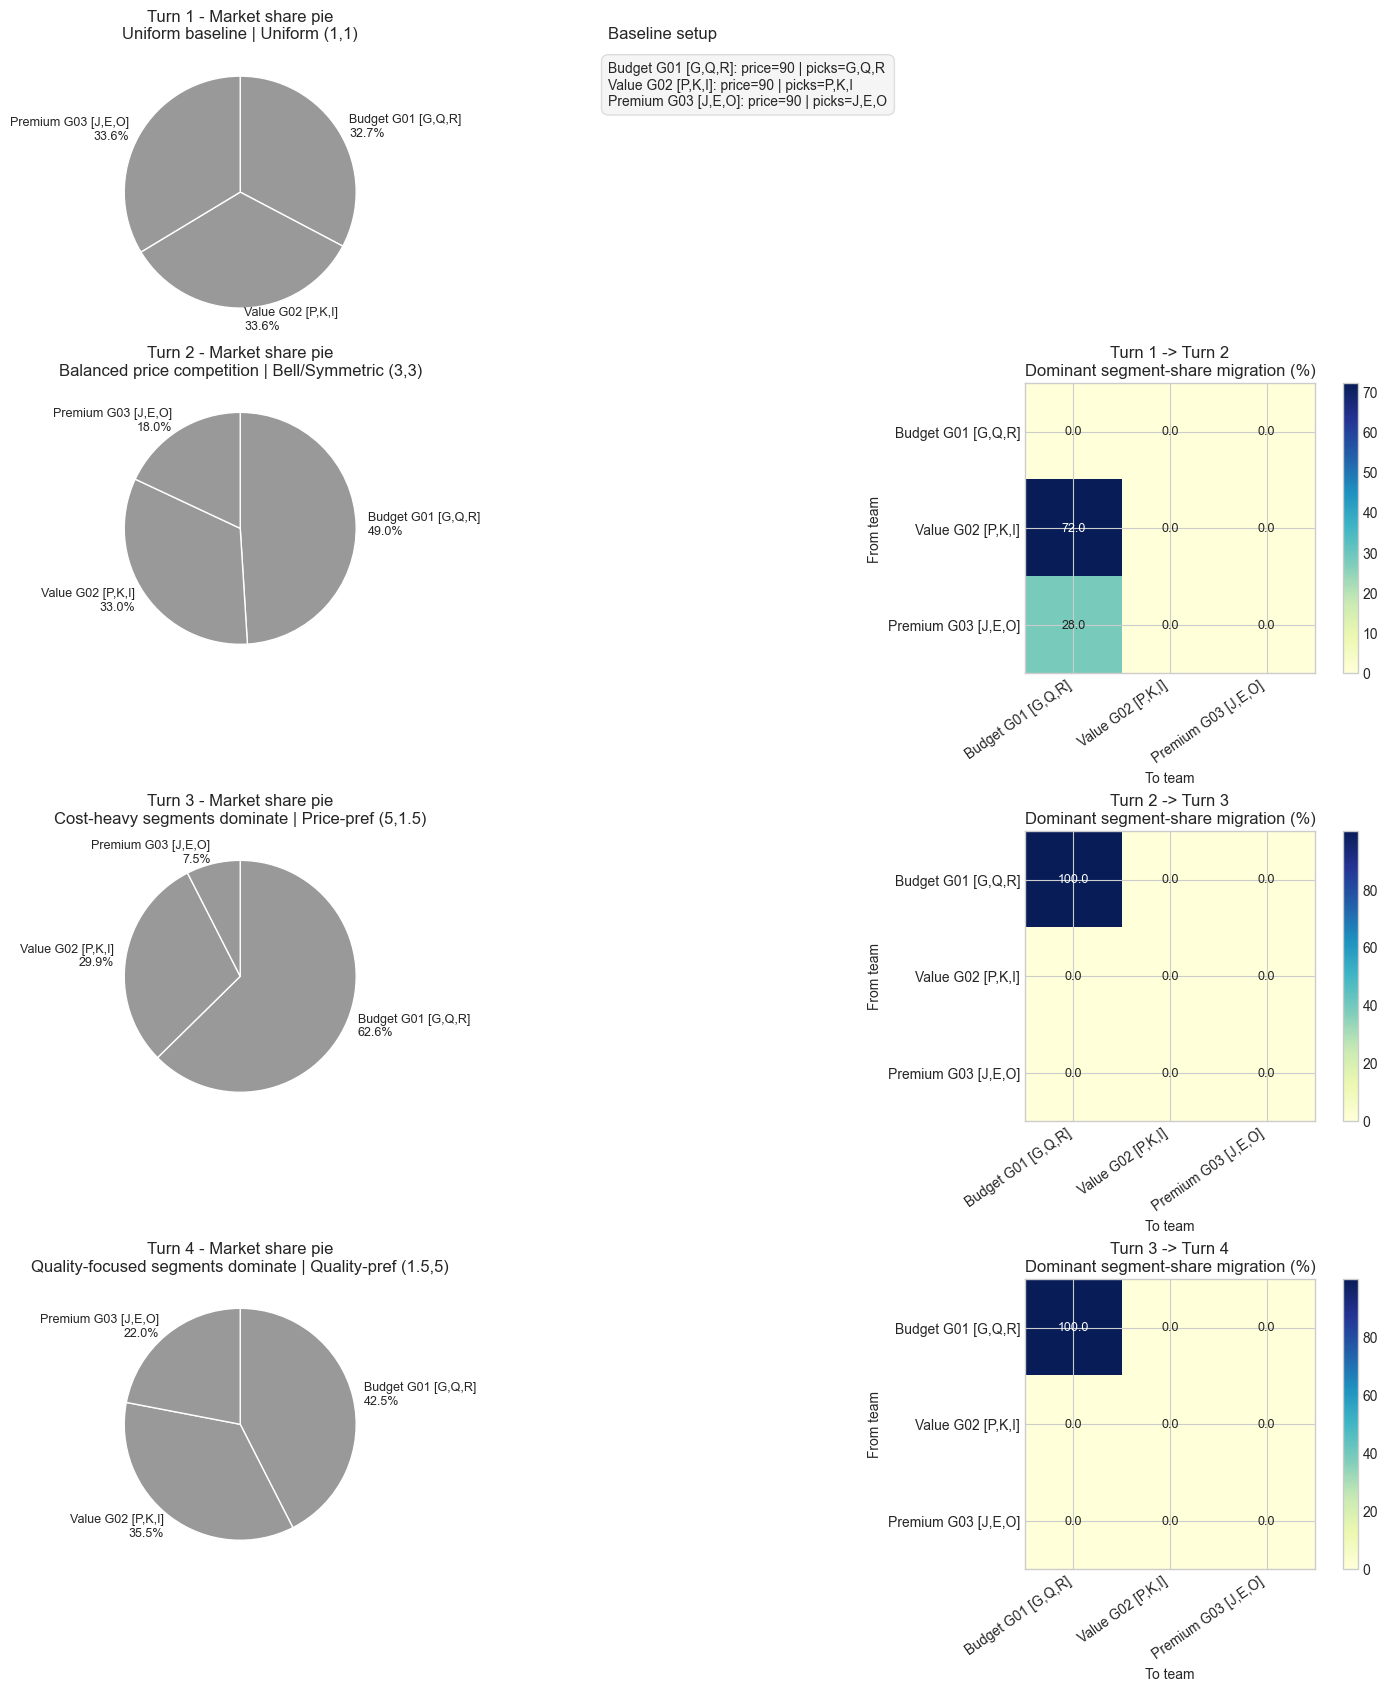

In [14]:
team_order = list(df_turn_summary['team'].drop_duplicates())
turn_order = (
    df_turn_summary[['turn_number', 'turn', 'scenario', 'distribution_name']]
    .drop_duplicates()
    .sort_values('turn_number')
)

fig, axes = plt.subplots(len(turn_order), 2, figsize=(15, 4.2 * len(turn_order)), constrained_layout=True)
if len(turn_order) == 1:
    axes = np.array([axes])

for row_idx, turn_row in enumerate(turn_order.itertuples(index=False)):
    turn = turn_row.turn
    pie_ax = axes[row_idx, 0]
    transfer_ax = axes[row_idx, 1]

    turn_df = (
        df_turn_summary[df_turn_summary['turn'] == turn]
        .set_index('team')
        .reindex(team_order)
        .fillna(0)
    )
    shares = turn_df['demand_share_pct']
    colors = [TEAM_COLORS.get(team, '#999999') for team in team_order]
    pie_ax.pie(
        shares,
        labels=[team + chr(10) + f"{value:.1f}%" for team, value in shares.items()],
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        textprops={'fontsize': 9},
    )
    pie_ax.set_title(f"{turn} - Market share pie" + chr(10) + f"{turn_row.scenario} | {turn_row.distribution_name}")

    if row_idx == 0:
        info = turn_df.reset_index()[['team', 'price', 'picks']]
        transfer_ax.axis('off')
        transfer_ax.set_title('Baseline setup', loc='left')
        text_lines = [
            f"{r.team}: price={int(r.price)} | picks={r.picks}"
            for r in info.itertuples(index=False)
        ]
        transfer_ax.text(
            0.0, 0.95,
            chr(10).join(text_lines),
            va='top', ha='left', fontsize=10,
            bbox={'facecolor': '#f5f5f5', 'edgecolor': '#dddddd', 'boxstyle': 'round,pad=0.5'},
        )
    else:
        prev_turn = turn_order.iloc[row_idx - 1]['turn']
        transition_label = f'{prev_turn} -> {turn}'
        matrix = (
            df_turn_transitions[df_turn_transitions['transition'] == transition_label]
            .pivot_table(index='from_team', columns='to_team', values='segment_weight_pct', aggfunc='sum')
            .reindex(index=team_order, columns=team_order, fill_value=0)
        )
        im = transfer_ax.imshow(matrix.values, cmap='YlGnBu')
        transfer_ax.set_xticks(range(len(team_order)))
        transfer_ax.set_xticklabels(team_order, rotation=35, ha='right')
        transfer_ax.set_yticks(range(len(team_order)))
        transfer_ax.set_yticklabels(team_order)
        transfer_ax.set_xlabel('To team')
        transfer_ax.set_ylabel('From team')
        transfer_ax.set_title(transition_label + chr(10) + 'Dominant segment-share migration (%)')
        for i in range(len(team_order)):
            for j in range(len(team_order)):
                transfer_ax.text(
                    j, i, f"{matrix.iloc[i, j]:.1f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if matrix.iloc[i, j] > matrix.values.max() * 0.5 else '#222222',
                )
        fig.colorbar(im, ax=transfer_ax, fraction=0.046, pad=0.04)

plt.show()


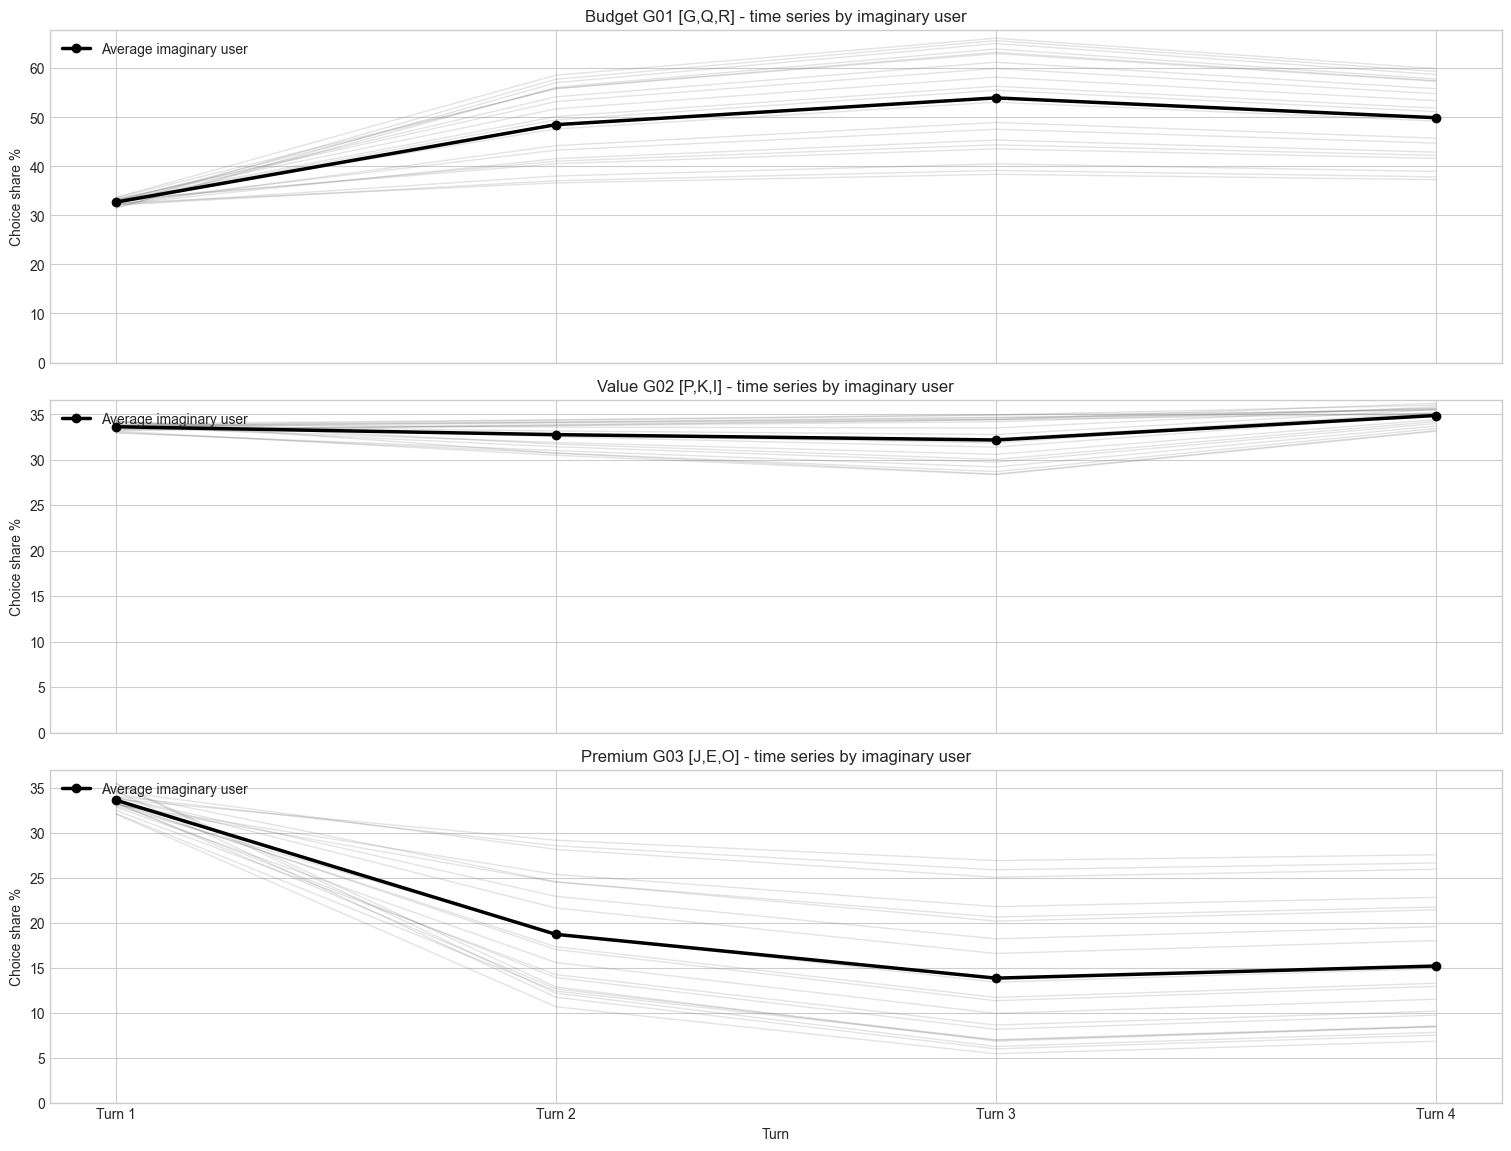

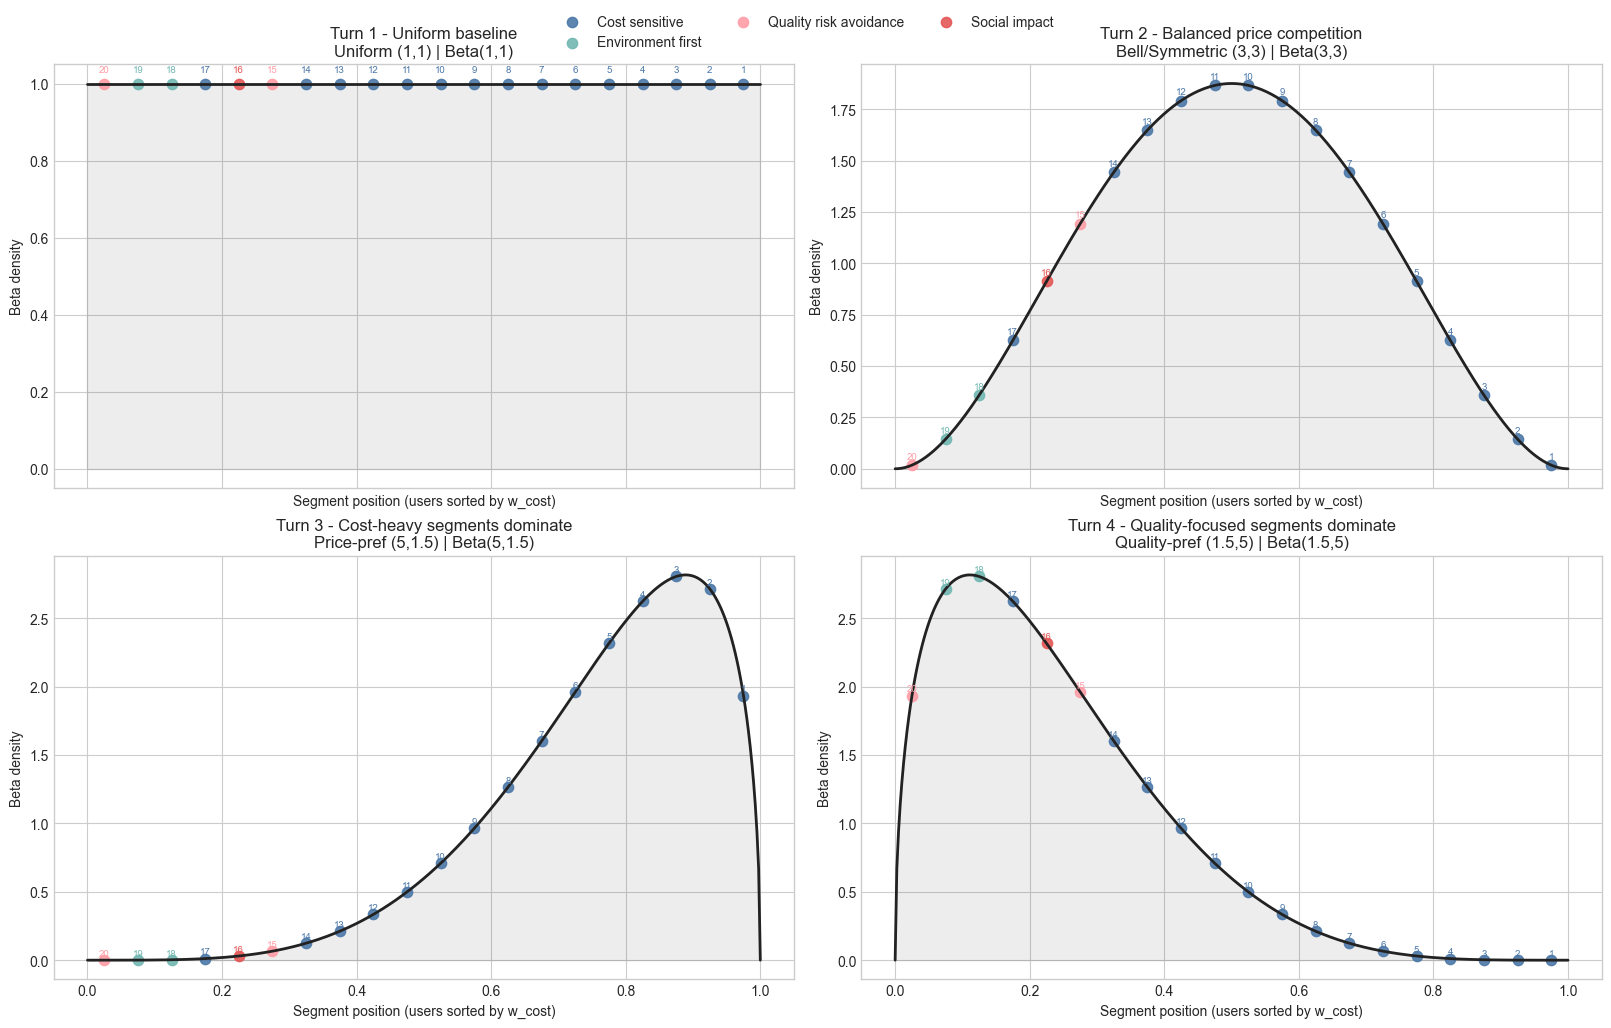

In [15]:
team_order = list(df_turn_summary['team'].drop_duplicates())
turn_ticks = turn_order['turn_number'].tolist()
turn_labels = turn_order['turn'].tolist()

fig, axes = plt.subplots(len(team_order), 1, figsize=(15, 3.8 * len(team_order)), sharex=True, constrained_layout=True)
if len(team_order) == 1:
    axes = [axes]

for ax, team in zip(axes, team_order):
    team_df = (
        df_turn_allocations[df_turn_allocations['team'] == team]
        .sort_values(['segment_rank', 'turn_number'])
    )
    color = TEAM_COLORS.get(team, '#666666')
    for segment_id, seg_df in team_df.groupby('segment_id'):
        ax.plot(
            seg_df['turn_number'],
            seg_df['team_segment_share_pct'],
            color=color,
            alpha=0.18,
            linewidth=1,
        )
    avg_line = team_df.groupby('turn_number', as_index=True)['team_segment_share_pct'].mean()
    ax.plot(avg_line.index, avg_line.values, color='black', linewidth=2.5, marker='o', label='Average imaginary user')
    ax.set_ylabel('Choice share %')
    ax.set_title(f'{team} - time series by imaginary user')
    ax.legend(loc='upper left')
    ax.set_ylim(bottom=0)

axes[-1].set_xticks(turn_ticks)
axes[-1].set_xticklabels(turn_labels)
axes[-1].set_xlabel('Turn')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, constrained_layout=True)
axes = axes.flatten()
legend_handles = {}

for ax, turn_row in zip(axes, turn_order.itertuples(index=False)):
    seg_df = (
        df_turn_segments[df_turn_segments['turn'] == turn_row.turn]
        .sort_values('segment_position')
        .copy()
    )
    density = BetaDensity(seg_df['beta_alpha'].iloc[0], seg_df['beta_beta'].iloc[0])
    x_grid, y_grid = density.sample_grid(400)
    ax.plot(x_grid, y_grid, color='#222222', linewidth=2)
    ax.fill_between(x_grid, 0, y_grid, color='#222222', alpha=0.08)

    for pref, pref_df in seg_df.groupby('dominant_preference'):
        color = PREFERENCE_COLORS.get(pref, '#888888')
        scatter = ax.scatter(
            pref_df['segment_position'],
            pref_df['density_raw'],
            s=55,
            color=color,
            alpha=0.9,
            label=pref,
        )
        legend_handles[pref] = scatter
        for row in pref_df.itertuples(index=False):
            ax.text(row.segment_position, row.density_raw + 0.03, str(row.segment_id),
                    fontsize=7, ha='center', color=color)

    ax.set_title(
        f"{turn_row.turn} - {turn_row.scenario}" + chr(10) +
        f"{seg_df['distribution_name'].iloc[0]} | {seg_df['distribution'].iloc[0]}"
    )
    ax.set_xlabel('Segment position (users sorted by w_cost)')
    ax.set_ylabel('Beta density')

for extra_ax in axes[len(turn_order):]:
    extra_ax.axis('off')

fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
)
plt.show()


## Export to Excel

In [16]:
OUTPUT_PATH = Path('market_simulation_results.xlsx')

# Prepare extra pivot sheets
pivot_exp1_profit = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='profit_total', aggfunc='first').round(1)
pivot_exp1_utility = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='utility_total', aggfunc='first').round(3)

pivot_exp2_profit = df_exp2[df_exp2['feasible']].pivot_table(
    index='beta_config', columns=['set','price'], values='profit_total', aggfunc='first').round(1)

team_a_name = group_spec(0, prefix='TeamA ')[0]
team_b_name = group_spec(1, prefix='TeamB ')[0]
a_demand = df_exp3[df_exp3['team']==team_a_name].pivot_table(
    index='price_A', columns='price_B', values='demand_share_pct', aggfunc='first').round(1)
a_profit = df_exp3[df_exp3['team']==team_a_name].pivot_table(
    index='price_A', columns='price_B', values='realized_profit', aggfunc='first').round(0)
b_profit = df_exp3[df_exp3['team']==team_b_name].pivot_table(
    index='price_A', columns='price_B', values='realized_profit', aggfunc='first').round(0)

delta_share = df_exp6[df_exp6['beta_config']=='Bell(3,3)'].pivot_table(
    index='delta', columns='team', values='demand_share_pct', aggfunc='first').round(1)

transfer_pivot = df_turn_transitions.pivot_table(
    index=['transition', 'from_team'], columns='to_team', values='segment_weight_pct', aggfunc='sum'
).round(2)

user_time_series = df_turn_allocations.pivot_table(
    index=['segment_id', 'user_id', 'dominant_preference'],
    columns=['turn', 'team'],
    values='team_segment_share_pct',
    aggfunc='first',
).round(2)

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    # Raw data
    df_exp1.to_excel(writer, sheet_name='E1_SingleTeam_Raw', index=False)
    df_exp2.to_excel(writer, sheet_name='E2_BetaEffect_Raw', index=False)
    df_exp3.to_excel(writer, sheet_name='E3_PriceWar_Raw', index=False)
    df_exp4.to_excel(writer, sheet_name='E4_BetaSweep_Raw', index=False)
    df_exp5.to_excel(writer, sheet_name='E5_ThreeTeam_Raw', index=False)
    df_exp6.to_excel(writer, sheet_name='E6_Delta_Raw', index=False)
    df_exp6b.to_excel(writer, sheet_name='E6b_PriceXDelta_Raw', index=False)
    df_turn_summary.to_excel(writer, sheet_name='V1_TurnSummary', index=False)
    df_turn_allocations.to_excel(writer, sheet_name='V1_TurnAlloc_Raw', index=False)
    df_turn_segments.to_excel(writer, sheet_name='V1_TurnSegments', index=False)
    df_turn_transitions.to_excel(writer, sheet_name='V1_Transfers_Raw', index=False)
    # Pivot tables
    pivot_exp1_profit.to_excel(writer, sheet_name='E1_Profit_Pivot')
    pivot_exp1_utility.to_excel(writer, sheet_name='E1_Utility_Pivot')
    pivot_exp2_profit.to_excel(writer, sheet_name='E2_Beta_Profit_Pivot')
    a_demand.to_excel(writer, sheet_name='E3_TeamA_Demand_Pivot')
    a_profit.to_excel(writer, sheet_name='E3_TeamA_Profit_Pivot')
    b_profit.to_excel(writer, sheet_name='E3_TeamB_Profit_Pivot')
    delta_share.to_excel(writer, sheet_name='E6_Delta_Demand_Pivot')
    pivot6b.to_excel(writer, sheet_name='E6b_PriceXDelta_Pivot')
    transfer_pivot.to_excel(writer, sheet_name='V1_Transfers_Pivot')
    user_time_series.to_excel(writer, sheet_name='V1_User_TimeSeries')

print(f'Saved -> {OUTPUT_PATH.resolve()}')
print(f'Total rows across all experiments: {sum(len(d) for d in [df_exp1,df_exp2,df_exp3,df_exp4,df_exp5,df_exp6,df_exp6b])}')


Saved -> C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app\server\tests\market_simulation_results.xlsx
Total rows across all experiments: 1087


## Quick Summary
Key findings printed for fast review.

In [17]:
print('='*60)
print('SIMULATION SUMMARY')
print('='*60)

print()
print('--- Feasibility check ---')
for sname, picks in SUPPLIER_SETS.items():
    a = avg_attrs(picks)
    feasible = is_feasible(picks)
    print(f"  {sname:12s} env={a.get('avg_env',0):.2f} social={a.get('avg_social',0):.2f} cost={a.get('avg_cost',0):.2f}  {'FEASIBLE' if feasible else 'INFEASIBLE'}")

print()
print('--- Exp 1: Best single-team profit @ default Beta(3,3) ---')
best1 = df_exp1[df_exp1['feasible']].sort_values('profit_total', ascending=False)
for _, r in best1.head(5).iterrows():
    print(f"  {r['set']:12s} @ price={r['price']:3.0f}  profit={r['profit_total']:8.1f}  utility={r['utility_total']:.2f}")

print()
print('--- Exp 3: Nash equilibrium hint (highest combined profit) ---')
exp3_combined = df_exp3.groupby(['price_A','price_B'])['realized_profit'].sum().reset_index()
best3 = exp3_combined.sort_values('realized_profit', ascending=False).head(5)
for _, r in best3.iterrows():
    print(f"  A={r['price_A']:3.0f} vs B={r['price_B']:3.0f}  combined_profit={r['realized_profit']:.0f}")

print()
print('--- Exp 6: Effect of delta on market share spread (Bell beta) ---')
for delta in [0.01, 0.10, 0.50]:
    sub = df_exp6[(df_exp6['delta']==delta) & (df_exp6['beta_config']=='Bell(3,3)')]
    rng = sub['demand_share_pct'].max() - sub['demand_share_pct'].min()
    print(f"  delta={delta:.2f}  share spread={rng:.1f}pp  (min={sub['demand_share_pct'].min():.1f}% max={sub['demand_share_pct'].max():.1f}%)")

print()
print('--- Visualization turns: round leaders ---')
turn_leaders = (
    df_turn_summary.sort_values(['turn_number', 'demand_share_pct'], ascending=[True, False])
    .groupby('turn', as_index=False)
    .head(1)
)
for _, r in turn_leaders.iterrows():
    print(f"  {r['turn']}: {r['team']} leads with {r['demand_share_pct']:.1f}% ({r['distribution_name']})")

print()
print('--- Biggest dominant-share migrations ---')
share_moves = (
    df_turn_transitions[df_turn_transitions['is_switch']]
    .groupby(['transition', 'from_team', 'to_team'], as_index=False)['segment_weight_pct']
    .sum()
    .sort_values('segment_weight_pct', ascending=False)
    .head(5)
)
for _, r in share_moves.iterrows():
    print(f"  {r['transition']}: {r['segment_weight_pct']:.1f}% segment weight moved {r['from_team']} -> {r['to_team']}")

print()
print('All results saved to: market_simulation_results.xlsx')


SIMULATION SUMMARY

--- Feasibility check ---
  G01 [G,Q,R]  env=2.73 social=2.63 cost=3.36  FEASIBLE
  G02 [P,K,I]  env=2.59 social=2.59 cost=2.17  FEASIBLE
  G03 [J,E,O]  env=2.25 social=2.92 cost=2.58  FEASIBLE
  G04 [D,K,C]  env=2.69 social=2.86 cost=2.42  FEASIBLE
  G05 [A,E,L]  env=2.66 social=2.79 cost=2.29  FEASIBLE
  G06 [P,N,L]  env=2.70 social=1.40 cost=2.53  FEASIBLE
  G07 [M,B,F]  env=1.74 social=2.96 cost=3.29  FEASIBLE
  G08 [J,N,C]  env=2.46 social=2.13 cost=3.32  FEASIBLE
  G09 [D,B,C]  env=2.36 social=2.21 cost=3.27  FEASIBLE
  G10 [D,N,R]  env=2.44 social=0.89 cost=4.20  FEASIBLE
  G11 [A,B,C]  env=2.50 social=2.79 cost=3.21  FEASIBLE

--- Exp 1: Best single-team profit @ default Beta(3,3) ---
  G06 [P,N,L]  @ price=100  profit=   753.6  utility=9.28
  G06 [P,N,L]  @ price= 90  profit=   748.4  utility=10.54
  G02 [P,K,I]  @ price= 90  profit=   743.3  utility=7.91
  G06 [P,N,L]  @ price=110  profit=   741.7  utility=8.14
  G02 [P,K,I]  @ price=100  profit=   739.1  